In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jun  4 21:33:25 2022

@author: ixn004
"""
#July 10, 2025


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

#from pyswarm import pso
from pyswarms.single.global_best import GlobalBestPSO #Date: Macrh 30,2024
from calculate_pZAP import run_bionetgen
from interpolation import spline
from ca_ODE import calcium, solve
from interpolation_exp_data import exp_idata


from data_slice import data_after_tstart
from ZAP_SYK_SSR_fit import calculate_residue
from calculate_SSR_gamma import gamma_PZAP
from calculate_SSR_zeta import zeta_PZAP    
from calculate_SSR_mixed import mixed_PZAP
import sys
      


In [2]:
# data_gamma=pd.read_csv('../hCD16_Ca_expt/ca_data/gamma.dat',sep="\t", comment='#', header=None)
# data_zeta=pd.read_csv('../hCD16_Ca_expt/ca_data/zeta.dat',sep="\t", comment='#', header=None)
# data_mixed=pd.read_csv('../hCD16_Ca_expt/ca_data/mixed.dat',sep="\t", comment='#', header=None)


data_gamma=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/gamma_scaled.dat',sep="\t", comment='#', header=None)
data_zeta=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/zeta_scaled.dat',sep="\t", comment='#', header=None)
data_mixed=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/mixed_scaled.dat',sep="\t", comment='#', header=None)

global exp_time_gamma, exp_data_gamma, exp_time_zeta, exp_data_zeta, exp_time_mixed, exp_data_mixed
#if the data has a time column:
start_time=time.time()

data_gamma=np.asarray(data_gamma) 
data_zeta=np.asarray(data_zeta)
data_mixed=np.asarray(data_mixed)

exp_time_gamma=data_gamma[:,0]
exp_data_gamma=data_gamma[:,1]

exp_time_zeta=data_zeta[:,0]
exp_data_zeta=data_zeta[:,1]

exp_time_mixed=data_mixed[:,0]
exp_data_mixed=data_mixed[:,1]





    


In [3]:


estimates=[5.402591891828305, 	0.34509429112133405, -2.041567760932002, 1.7735646976771902, 2.7414322073309236, 2.5330046042818015, 687.6299531733689]
estimates=[5.187041324378862, 0.13752151267825669, -2.0518004362227082, 2.072633918509969, 2.9201735453789475, 2.9822022932883097, 673.4472217157079]
estimates=[5.447824481234601, 0.5318649156221386, -2.1728448820771784, 1.4871888907536615, 2.979913417868518, 2.617342457809944, 890.3740498542815]
estimates=[5.634242987197348, 0.6957451193259656, -2.1259994632125485, 2.8376714264172365, 3.18877587716635, 2.7618549035654607, 872.5488651866173]
estimates=[4.605137407566538, -0.3550553552498677, -2.1310232543993184, 2.3565433265788, 2.9665683679264596, 2.9554405226898046, 793.8181437990933]
estimates=[4.882889227827497, -0.14924883865790955, -2.091248419834949, 2.6558849182283195, 3.189827436504974, 3.183417389060109, 561.7418221960589]

C1 = 10**estimates[0]
C2 = 10**estimates[1]
g = 10**estimates[2]
a0_zeta=10**estimates[3]
a0_mixed= a0_zeta*1.6 
a0_gamma= a0_zeta*0.53
ZAP0= 10**estimates[4]
SYK0= 10**estimates[5]

# C1=134417.2326483444
# C2=1.3585291452346677
# g=0.008280742501441098
# a0_zeta=364.00894839716716
# a0_mixed=582.4143174354675
# a0_gamma=192.92474265049862
# ZAP0=554.4111168423424
# SYK0=561.9570448218436


n = 3  # Number of bionetgen runs

dir_name="analysis"
print(f"C1={C1}")
print(f"C2={C2}")
print(f"g={g}")
print(f"a0_zeta={a0_zeta}")
print(f"a0_mixed={a0_mixed}")
print(f"a0_gamma={a0_gamma}")
print(f"ZAP0={ZAP0}")
print(f"SYK0={SYK0}")

C1=76364.0982669576
C2=0.7091713160937018
g=0.008104973144412215
a0_zeta=452.77758447860697
a0_mixed=724.4441351657712
a0_gamma=239.97211977366172
ZAP0=1548.201331064208
SYK0=1525.5181850921654


In [4]:

tnew_zeta, PZAP_zeta, PSYK_zeta, N, dir_name_zeta = zeta_PZAP(n, a0_zeta, ZAP0, SYK0, dir_name)
print(N)

A0= 452.77758447860697
ZAP0= 1548.201331064208
SYK0= 1525.5181850921654
Running bionetgen simulations in directory: zeta_runs/analysis
Running bionetgen simulations in directory: zeta_runs/analysis
2000
2000


In [5]:
tnew_mixed, PZAP_mixed, PSYK_mixed, N, dir_name_mixed = mixed_PZAP(n, a0_mixed, ZAP0, SYK0, dir_name)
print(N)

A0= 724.4441351657712
ZAP0= 1548.201331064208
SYK0= 1525.5181850921654
Running bionetgen simulations in directory: mixed_runs/analysis
Running bionetgen simulations in directory: mixed_runs/analysis
2000
2000


In [6]:
tnew_gamma, PZAP_gamma, PSYK_gamma, N, dir_name_gamma = gamma_PZAP(n, a0_gamma, ZAP0, SYK0, dir_name)
print(N)

A0= 239.97211977366172
ZAP0= 1548.201331064208
SYK0= 1525.5181850921654
Running bionetgen simulations in directory: gamma_runs/analysis
Running bionetgen simulations in directory: gamma_runs/analysis
2000
2000


In [7]:
print(N)

2000


In [8]:
import numpy as np

# Save zeta results in columnar format
with open("zeta_results.txt", "w") as f:
    #f.write("# Time\tPZAP\tPSYK\n")  # Header
    for i in range(len(tnew_zeta)):
        f.write(f"{tnew_zeta[i]}\t{PZAP_zeta[i]}\t{PSYK_zeta[i]}\n")

# Save mixed results in columnar format
with open("mixed_results.txt", "w") as f:
    #f.write("# Time\tPZAP\tPSYK\n")  # Header
    for i in range(len(tnew_mixed)):
        f.write(f"{tnew_mixed[i]}\t{PZAP_mixed[i]}\t{PSYK_mixed[i]}\n")

# Save gamma results in columnar format  
with open("gamma_results.txt", "w") as f:
    #f.write("# Time\tPZAP\tPSYK\n")  # Header
    for i in range(len(tnew_gamma)):
        f.write(f"{tnew_gamma[i]}\t{PZAP_gamma[i]}\t{PSYK_gamma[i]}\n")

print("Data saved successfully in columnar format!")
print(f"Zeta: {len(tnew_zeta)} time points")
print(f"Mixed: {len(tnew_mixed)} time points") 
print(f"Gamma: {len(tnew_gamma)} time points")

Data saved successfully in columnar format!
Zeta: 2000 time points
Mixed: 2000 time points
Gamma: 2000 time points


In [9]:
k3=(np.max(PZAP_zeta))/2.0

In [ ]:

      

residue_zeta,t_zeta,EXPT_zeta,Ca_zeta = calculate_residue(n, tnew_zeta, PZAP_zeta, PSYK_zeta, exp_time_zeta, exp_data_zeta, C1, C2, g, N,k3)
residue_mixed,t_mixed,EXPT_mixed,Ca_mixed = calculate_residue(n, tnew_mixed, PZAP_mixed, PSYK_mixed, exp_time_mixed, exp_data_mixed, C1, C2, g, N,k3)
residue_gamma,t_gamma,EXPT_gamma,Ca_gamma = calculate_residue(n, tnew_gamma, PZAP_gamma, PSYK_gamma, exp_time_gamma, exp_data_gamma, C1, C2, g, N,k3)

C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.16780605 ... 18338.9670739
 18319.19937382 18299.45298156]
C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 41737.61328
[41737.61328    41692.62349365 41647.68220909 ... 19588.40968012
 19567.2951901  19546.20345959]
C1 = 76364.0982669576C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 36345.51172
[36345.51172    36306.33418494 36267.19886626 ... 33323.22615193
 33292.80223086 33262.31153078]

C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 36345.51172
[36345.51172    36306.33418494 36267.19886626 ... 33323.22615193
 33292.80223086 33262.31153078]


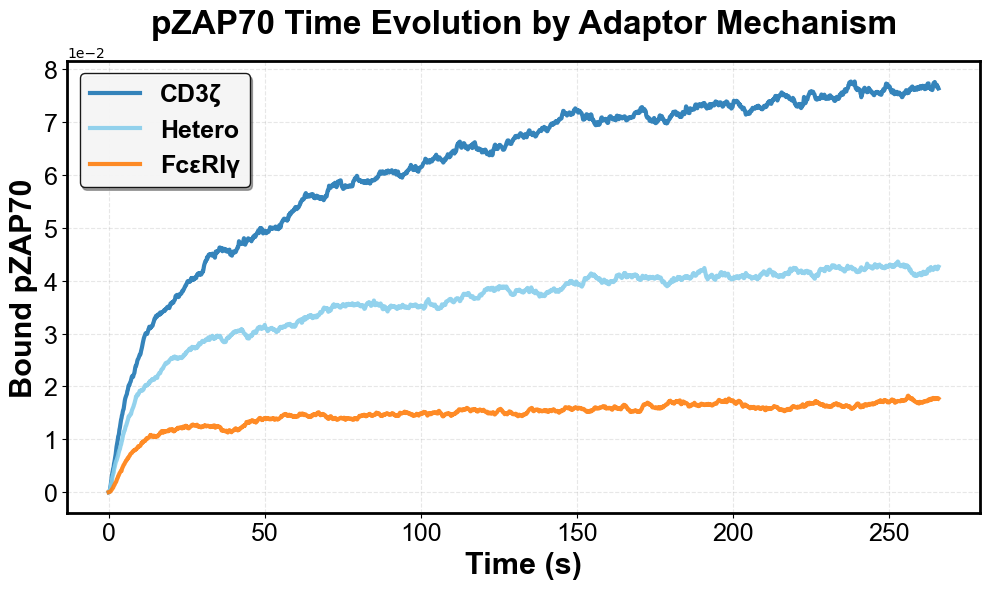

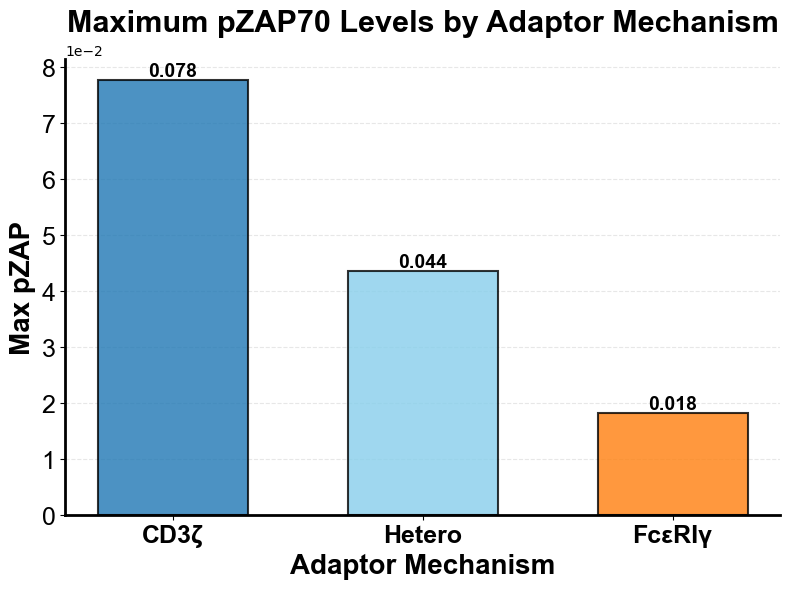

Total residue^(1/4) = 565.7649


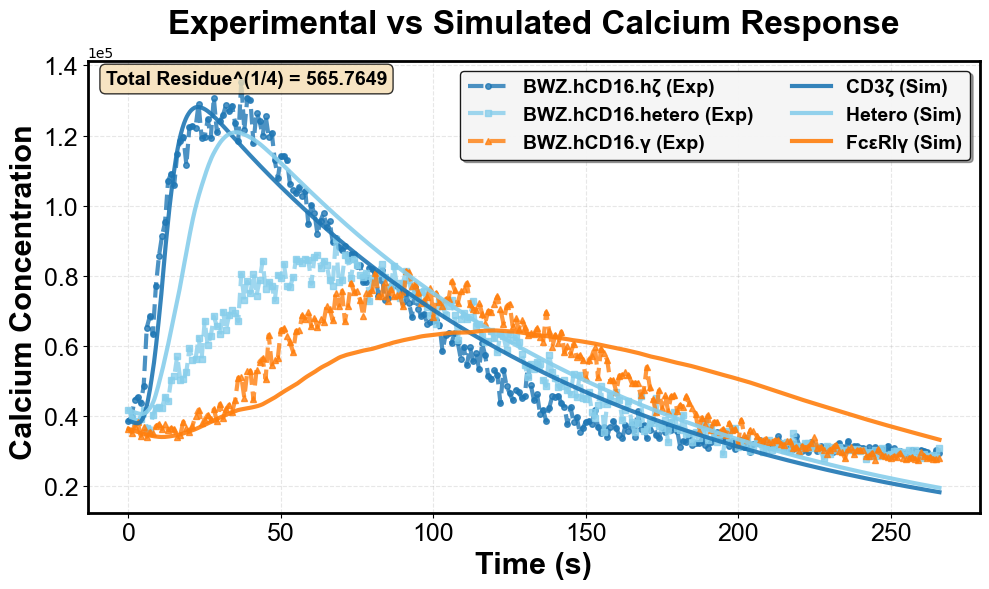

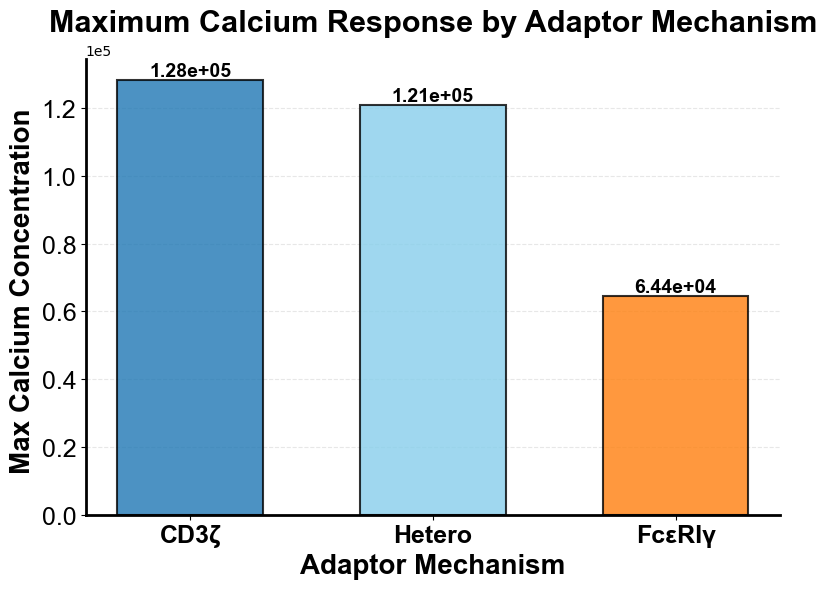

In [13]:
Vc=25.0 #pZAP molecules in the simulation box of size 25 um^3
z=602.0 #constant factor to convert from molecules/um3 to uM

# # Enhanced pZAP time series plot
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot with enhanced styling
# ax.plot(tnew_zeta, PSYK_zeta, label='CD3ζ', color='#1f77b4', linewidth=3, alpha=0.9)
# ax.plot(tnew_mixed, PSYK_mixed, label='Hetero', color='#87ceeb', linewidth=3, alpha=0.9)
# ax.plot(tnew_gamma, PSYK_gamma, label='FcεRIγ', color='#ff7f0e', linewidth=3, alpha=0.9)

# # Customize labels and title
# ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_ylabel('Total pSYK', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_title('pSYK Time Evolution by Adaptor Mechanism', 
#              fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# # Enhanced tick formatting
# ax.tick_params(axis='both', which='major', labelsize=18)
# plt.setp(ax.get_xticklabels(), fontfamily='Arial')
# plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# # Enhanced legend
# legend = ax.legend(prop={'family': 'Arial', 'size': 18, 'weight': 'bold'}, 
#                    frameon=True, fancybox=True, shadow=True, 
#                    framealpha=0.9, edgecolor='black')

# # Add grid
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_axisbelow(True)

# # Set spine styling
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_color('black')

# # Scientific notation if needed
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# plt.tight_layout()
# plt.show()


# Enhanced pZAP time series plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with enhanced styling
ax.plot(tnew_zeta, PZAP_zeta, label='CD3ζ', color='#1f77b4', linewidth=3, alpha=0.9)
ax.plot(tnew_mixed, PZAP_mixed, label='Hetero', color='#87ceeb', linewidth=3, alpha=0.9)
ax.plot(tnew_gamma, PZAP_gamma, label='FcεRIγ', color='#ff7f0e', linewidth=3, alpha=0.9)

# Customize labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Bound pZAP70', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('pZAP70 Time Evolution by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend
legend = ax.legend(prop={'family': 'Arial', 'size': 18, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Create figure with better design
fig, ax = plt.subplots(figsize=(8, 6))

# Data and labels
mechanisms = ['CD3ζ', 'Hetero', 'FcεRIγ']
max_values = [np.max(PZAP_zeta), np.max(PZAP_mixed), np.max(PZAP_gamma)]
colors = ['#1f77b4', '#87ceeb', '#ff7f0e']  # Professional color palette

# Create bars with enhanced styling
bars = ax.bar(mechanisms, max_values, 
              color=colors, 
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              width=0.6)

# Add value labels on top of bars
for bar, value in zip(bars, max_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}',
            ha='center', va='bottom', 
            fontfamily='Arial', fontsize=14, fontweight='bold')

# Customize the plot
ax.set_ylabel('Max pZAP', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_title('Maximum pZAP70 Levels by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_axisbelow(True)

# Set spine thickness and style
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scientific notation for y-axis if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout and show
plt.tight_layout()
plt.show()


# Enhanced experimental vs simulation calcium plot
fig, ax = plt.subplots(figsize=(10, 6))


# Experimental data with enhanced styling
ax.plot(exp_time_zeta, exp_data_zeta, color='#1f77b4', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hζ (Exp)', marker='o', markersize=4)
ax.plot(exp_time_mixed, exp_data_mixed, color='#87ceeb', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hetero (Exp)', marker='s', markersize=4)
ax.plot(exp_time_gamma, exp_data_gamma, color='#ff7f0e', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.γ (Exp)', marker='^', markersize=4)

# Simulation data with solid lines
ax.plot(t_zeta, Ca_zeta, color='#1f77b4', linewidth=3, alpha=0.9, label='CD3ζ (Sim)')
ax.plot(t_mixed, Ca_mixed, color='#87ceeb', linewidth=3, alpha=0.9, label='Hetero (Sim)')
ax.plot(t_gamma, Ca_gamma, color='#ff7f0e', linewidth=3, alpha=0.9, label='FcεRIγ (Sim)')

# Calculate and display residue
# Calculate and display residue
#residue_total = residue_zeta #+ residue_gamma
residue_total = residue_zeta #+ #residue_mixed
print(f"Total residue^(1/4) = {residue_total**(1/4):.4f}")

# Enhanced labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Calcium Concentration ', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('Experimental vs Simulated Calcium Response', 
             fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend with two columns
legend = ax.legend(prop={'family': 'Arial', 'size': 14, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black', ncol=2, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Add text box with residue information
textstr = f'Total Residue^(1/4) = {residue_total**(1/4):.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, fontfamily='Arial', fontweight='bold')

plt.tight_layout()
plt.show()

# Enhanced maximum calcium bar plot
fig, ax = plt.subplots(figsize=(8, 6))

# Data and labels
mechanisms = ['CD3ζ', 'Hetero', 'FcεRIγ']
max_calcium_values = [np.max(Ca_zeta), np.max(Ca_mixed), np.max(Ca_gamma)]
colors = ['#1f77b4', '#87ceeb', '#ff7f0e']  # Professional color palette

# Create bars with enhanced styling
bars = ax.bar(mechanisms, max_calcium_values, 
              color=colors, 
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              width=0.6)

# Add value labels on top of bars
for bar, value in zip(bars, max_calcium_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2e}',
            ha='center', va='bottom', 
            fontfamily='Arial', fontsize=14, fontweight='bold')

# Customize the plot
ax.set_ylabel('Max Calcium Concentration ', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_title('Maximum Calcium Response by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_axisbelow(True)

# Set spine thickness and style
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scientific notation for y-axis
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout and show
plt.tight_layout()
plt.show()


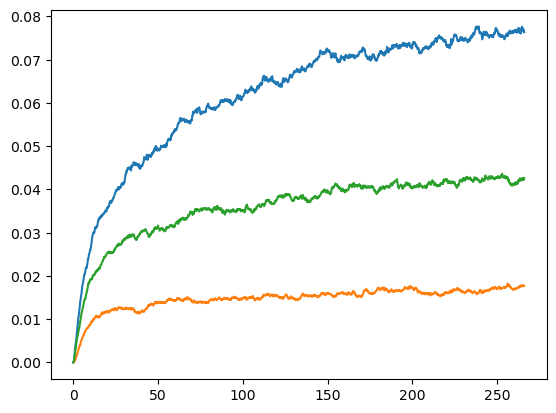

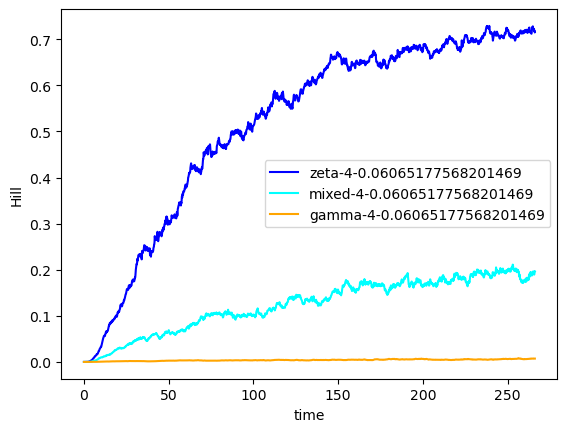

/tmp/ipykernel_1868289/2198576169.py:4: RuntimeWarning: invalid value encountered in divide
  yn=(x**n)/(x**n+k3**n)


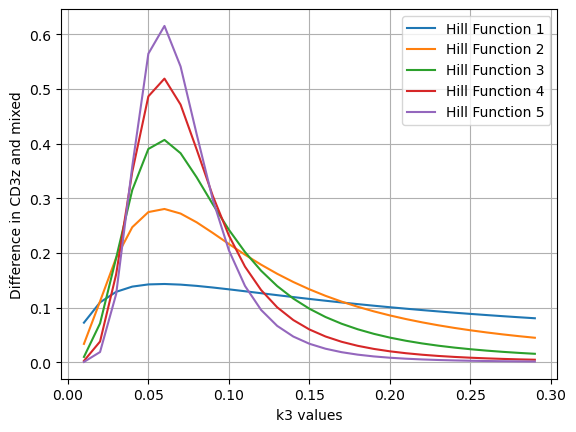

The arithmatic mean is at 0.06065177568201469


In [12]:
import matplotlib.pyplot as plt

def plot_hill_function(x,k3,n):
    yn=(x**n)/(x**n+k3**n)
    return yn

plt.figure()

PZAP_zeta=PZAP_zeta 
PZAP_mixed=PZAP_mixed 
PZAP_gamma=PZAP_gamma



plt.plot(t_zeta,PZAP_zeta)
plt.plot(t_zeta,PZAP_gamma)
plt.plot(t_zeta,PZAP_mixed)
plt.show()



k3=(np.max(PZAP_zeta)+np.max(PZAP_mixed))/2.0

#for i in range(len(k3)):
n=4
y_zeta=plot_hill_function(PZAP_zeta,k3,n)
plt.plot(t_zeta,y_zeta,'-',label=f'zeta-{n}-{k3}',color='blue')


y_mixed=plot_hill_function(PZAP_mixed,k3,n)
plt.plot(t_mixed,y_mixed,'-',label=f'mixed-{n}-{k3}',color='cyan')
#plt.plot(PZAP_mixed,yn,'--',label='mixed-2',color='cyan')

y_gamma=plot_hill_function(PZAP_gamma,k3,n)
plt.plot(t_gamma,y_gamma,'-',label=f'gamma-{n}-{k3}',color='orange')
#plt.plot(PZAP_gamma,yn,'--',label='gamma-2',color='orange'

plt.xlabel('time')
plt.ylabel('Hill')
plt.legend()
plt.show()


yn_zeta=plot_hill_function(PZAP_zeta,k3,n)
yn_mixed=plot_hill_function(PZAP_mixed,k3,n)
yn_gamma=plot_hill_function(PZAP_gamma,k3,n)

def diff_saturation_max(Z1, Z2):
    diff=np.max(Z1)-np.max(Z2)
    return diff

hill_1=[]
hill_2=[]
hill_3=[]
hill_4=[]
hill_5=[]
k=[]
for i in range(30):
    k.append(i*0.01)
    #print(f"k3 for iteration {i}: {k[i]}")
    n=1
    y_zeta=plot_hill_function(PZAP_zeta,k[i],n)
    y_mixed=plot_hill_function(PZAP_mixed,k[i],n)
    hill_1.append(diff_saturation_max(y_zeta,y_mixed))

    n=2
    yn_zeta=plot_hill_function(PZAP_zeta,k[i],n)
    yn_mixed=plot_hill_function(PZAP_mixed,k[i],n)
    hill_2.append(diff_saturation_max(yn_zeta,yn_mixed))

    n=3
    yn_zeta=plot_hill_function(PZAP_zeta,k[i],n)
    yn_mixed=plot_hill_function(PZAP_mixed,k[i],n)
    hill_3.append(diff_saturation_max(yn_zeta,yn_mixed))

    n=4
    yn_zeta=plot_hill_function(PZAP_zeta,k[i],n)
    yn_mixed=plot_hill_function(PZAP_mixed,k[i],n)
    hill_4.append(diff_saturation_max(yn_zeta,yn_mixed))

    n=5
    yn_zeta=plot_hill_function(PZAP_zeta,k[i],n)
    yn_mixed=plot_hill_function(PZAP_mixed,k[i],n)
    hill_5.append(diff_saturation_max(yn_zeta,yn_mixed))


plt.figure()
plt.plot(k, hill_1, label='Hill Function 1')
plt.plot(k, hill_2, label='Hill Function 2')
plt.plot(k, hill_3, label='Hill Function 3')
plt.plot(k, hill_4, label='Hill Function 4')
plt.plot(k, hill_5, label='Hill Function 5')
plt.xlabel('k3 values')
plt.grid(True)
plt.ylabel('Difference in CD3z and mixed')
plt.legend()
plt.show()

print(f"The arithmatic mean is at {np.mean([np.max(PZAP_zeta),np.max(PZAP_mixed)])}")